# Explanation Notebook for ScenarioModel4
*Model Type:* **LogisticRegression**
*User:* UserLR (Expertise: Advanced, Formats: [plainText, table, visual], Details: medium, Purpose: justification)
*Explanation Method:* SHAP


## Training the LogisticRegression Model
We train a **LogisticRegression** model on the provided dataset.


In [1]:
import warnings; warnings.filterwarnings('ignore')
!pip install -q scikit-learn pandas shap matplotlib
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"data/banknote.csv")
y = df['class']
X = df.drop(columns=['class']).values
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
    print('[Info] Used stratified split to preserve class proportions in train/test.')
except Exception:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    print('[Info] Used non-stratified split (stratification not applicable).')
class Dummy: pass
data = Dummy(); data.feature_names = list(df.drop(columns=['class']).columns)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
base_model = LogisticRegression(max_iter=1000, random_state=0)
model = make_pipeline(StandardScaler(), base_model)
print('[Info] Normalization enabled by training policy: using StandardScaler in a pipeline.')
model.fit(X_train, y_train)
print('Accuracy: LogisticRegression = ' + format(model.score(X_test, y_test), '.2f'))


[Info] Used stratified split to preserve class proportions in train/test.
[Info] Normalization enabled by training policy: using StandardScaler in a pipeline.
Accuracy: LogisticRegression = 0.99


## Explaining the model using SHAP
SHAP computes additive feature attributions and can support both local and global views.



[SHAP overview]
SHAP assigns additive feature attributions to explain a prediction.

[Plain-text explanation]
This explanation summarizes the main reasons behind the selected prediction.
 - Variance: SHAP=0.312300 | abs=0.312300
 - Skewness: SHAP=0.214366 | abs=0.214366
 - Curtosis: SHAP=-0.010399 | abs=0.010399
 - Entropy: SHAP=0.008379 | abs=0.008379

[Tabular explanation]
Columns: feature, signed SHAP value, and absolute magnitude.


,Feature,SHAP,AbsSHAP
0,Variance,0.312300,0.312300
1,Skewness,0.214366,0.214366
2,Curtosis,-0.010399,0.010399
3,Entropy,0.008379,0.008379



[Visual explanation]
How to read the plot: bar length shows the magnitude of SHAP influence; signed values in the table/plain-text output show the direction.


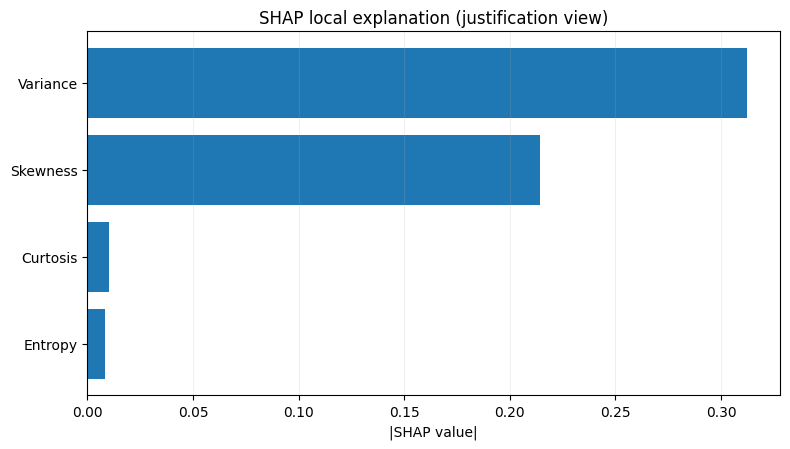

In [2]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt

def _get_feature_names():
    try:
        names = list(getattr(data, 'feature_names', []))
        if names and len(names) == X_train.shape[1]:
            return names
    except Exception:
        pass
    if 'df' in globals():
        cols = [c for c in df.columns if c.lower() not in ('label','target','y')]
        if len(cols) == X_train.shape[1]:
            return cols
    return [f'f{j}' for j in range(X_train.shape[1])]

RAW_NAMES = _get_feature_names()
def _humanize(name):
    s = name.replace('_',' ').strip()
    s = re.sub(r'(?<!^)(?=[A-Z])',' ', s)
    s = re.sub(r'\s+',' ', s).strip()
    return ' '.join([w.upper() if w.lower() in {'svm','pdp','ice','api','url'} else w.capitalize() for w in s.split(' ')])
HUMAN = [_humanize(n) for n in RAW_NAMES]

max_display = 6
table_rows = 10
curve_resolution = 24
ice_instances = 10
metric_digits = 4
figure_height = 4.6
line_width = 2.0
pdp_sample_rows = 8
ice_detailed_instances = 3
sampled_curve_points = 7
i = 0
print('\n[SHAP overview]')
print('SHAP assigns additive feature attributions to explain a prediction.')
import shap
background = X_train[:min(50, X_train.shape[0])]
if hasattr(model, 'predict_proba'):
    predict_fn = lambda X: model.predict_proba(np.array(X))
else:
    predict_fn = lambda X: np.array(model.predict(np.array(X))).reshape(-1, 1)
explainer = shap.Explainer(predict_fn, background)
X_one = X_test[i:i+1]
sv_one = explainer(X_one)
def _flatten_local(values):
    arr = np.array(values)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2:
        return arr[0]
    if arr.ndim == 3:
        class_idx = 1 if arr.shape[2] > 1 else 0
        return arr[0, :, class_idx]
    return arr.reshape(-1)
vals = _flatten_local(sv_one.values)
pairs = list(zip(HUMAN, vals))
pairs = sorted(pairs, key=lambda x: abs(float(x[1])), reverse=True)[:max_display]
df_shap = pd.DataFrame({'Feature':[p[0] for p in pairs], 'SHAP':[float(p[1]) for p in pairs]})
df_shap['AbsSHAP'] = df_shap['SHAP'].abs()
print('\n[Plain-text explanation]')
print('This explanation summarizes the main reasons behind the selected prediction.')
for _, r in df_shap.iterrows():
    print(' - ' + str(r['Feature']) + ': SHAP=' + format(r['SHAP'], '.6f') + ' | abs=' + format(r['AbsSHAP'], '.6f'))
print('\n[Tabular explanation]')
print('Columns: feature, signed SHAP value, and absolute magnitude.')
display(df_shap[['Feature','SHAP','AbsSHAP']].head(table_rows))
print('\n[Visual explanation]')
print('How to read the plot: bar length shows the magnitude of SHAP influence; signed values in the table/plain-text output show the direction.')
plot_df = df_shap.sort_values('AbsSHAP')
plt.figure(figsize=(8, figure_height))
plt.barh(plot_df['Feature'], plot_df['AbsSHAP'])
plt.title('SHAP local explanation (justification view)')
plt.xlabel('|SHAP value|')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout(); plt.show()
